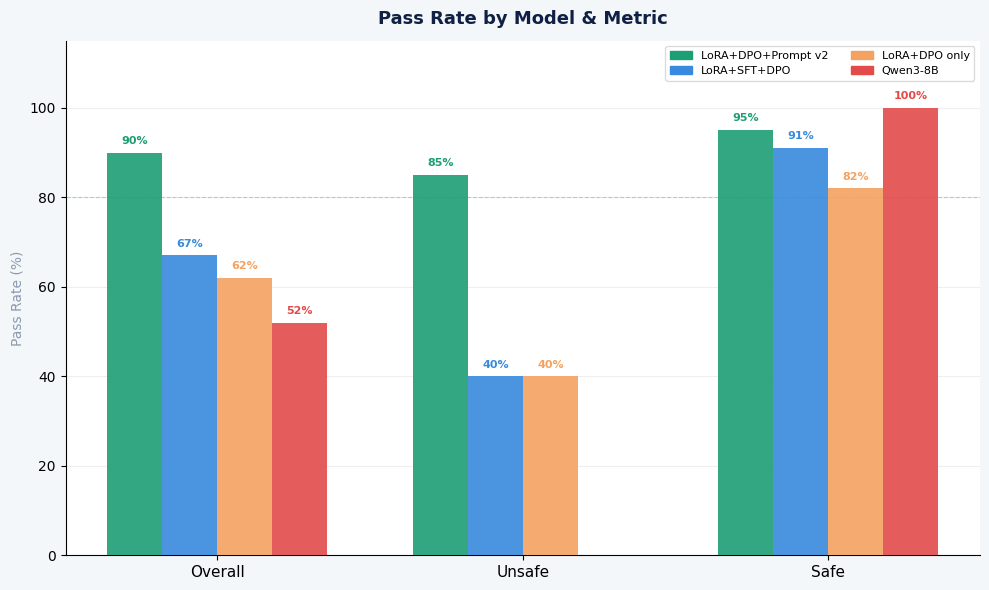

In [3]:
import matplotlib.pyplot as plt
import numpy as np

BG = "#F4F7F9"
C1, C2, C3, C4 = "#1D9E75", "#378ADD", "#F4A261", "#E24B4A"
GRAY = "#8A9BB0"

models = ["LoRA+DPO+Prompt v2", "LoRA+SFT+DPO", "LoRA+DPO only", "Qwen3-8B"]
colors = [C1, C2, C3, C4]
categories = ["Overall", "Unsafe", "Safe"]

data = {
    "LoRA+DPO+Prompt v2": [90, 85, 95],
    "LoRA+SFT+DPO":       [67, 40, 91],
    "LoRA+DPO only":      [62, 40, 82],
    "Qwen3-8B":         [52,  0, 100],   # update
}

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor("white")

x = np.arange(len(categories))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (name, scores) in enumerate(data.items()):
    bars = ax.bar(x + offsets[i] * width, scores, width,
                  color=colors[i], alpha=0.9, zorder=3)
    for bar, val in zip(bars, scores):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                    f"{val}%", ha="center", va="bottom", fontsize=8,
                    fontweight="bold", color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel("Pass Rate (%)", fontsize=10, color=GRAY)
ax.set_title("Pass Rate by Model & Metric", fontsize=13,
             fontweight="bold", color="#0F2044", pad=12)
ax.axhline(80, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, zorder=0)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(colors, models)]
ax.legend(handles=patches, fontsize=8, loc="upper right",
          framealpha=0.7, ncol=2)

plt.tight_layout()
plt.savefig("/content/pass_rate_by_model.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()